# Load data

In [1]:
# Imports
import numpy as np
import BLEanalysis.angleinference as AngleInference
np.set_printoptions(precision=2,suppress=True)
import matplotlib.pyplot as plt
from BLEanalysis.signals import Signals
from BLEanalysis.angleinference import AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.angleinference import AnglesUsePeaks
from scipy.stats import circmean
import pandas as pd

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
# Training data used for angle inference, consists of reading many packets over many rotations of the transmitter at a different
# location to that of the test data. This file was taken at Ponderosa Park, Sheffield, UK
trainingsigs = Signals("../bluetooth_experiments/no rf amp experiments/noamploc2long.log", ['d'], angleOffset = 38)

# Helper function to subsample randomly from a set of signal strengths
def randomSampleFromBurstDict(dict, n):
    samples = {}
    samples['transmitter_position'] = dict['transmitter_position']
    samples['rssis'] = []
    samples['angles'] = []
    samples['times'] = []
    # Randomly select unique indices
    rand_indices = np.random.choice(len(dict['rssis']), size=n, replace=False)

    # Collect samples at those indices
    samples['rssis'] = np.array([dict['rssis'][i] for i in rand_indices])
    samples['angles'] = np.array([dict['angles'][i] for i in rand_indices])
    samples['times'] = np.array([dict['times'][i] for i in rand_indices])

    return samples

# Helper function to calculate error between two angles
def angularDistance(a1, a2):
    diff = abs(a1 - a2) % 360
    return np.abs(min(diff, 360 - diff))

Standardising angles and times (shifting by 38.00 degrees)


Standardising angles and times (shifting by 90.00 degrees)
Transmitter       Number of records
        c                 8315
Standardising angles and times (shifting by 38.00 degrees)
100000ms out of 733482ms added to table.
110000ms out of 733482ms added to table.
120000ms out of 733482ms added to table.
130000ms out of 733482ms added to table.
140000ms out of 733482ms added to table.
150000ms out of 733482ms added to table.
160000ms out of 733482ms added to table.
170000ms out of 733482ms added to table.
180000ms out of 733482ms added to table.
190000ms out of 733482ms added to table.
200000ms out of 733482ms added to table.
210000ms out of 733482ms added to table.
220000ms out of 733482ms added to table.
230000ms out of 733482ms added to table.
240000ms out of 733482ms added to table.
250000ms out of 733482ms added to table.
260000ms out of 733482ms added to table.
270000ms out of 733482ms added to table.
280000ms out of 733482ms added to table.
290000ms out of 733482ms added to ta

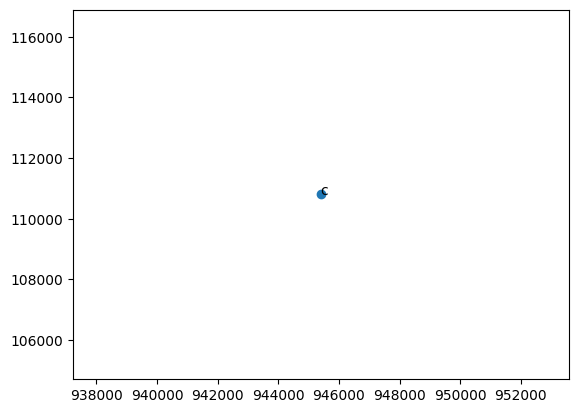

In [3]:
# Load in test data, measured at Common Lane Open Space, Sheffield, UK
testsigs = Signals("../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log",['c'],angleOffset= 90)
testsigs.configureTransmitter('c',0,0,1,1)
testsigs.noramliseTransmitterLocs()
testsigs.summarise(showNormalised = False)
# Build rejection sampling table
rejectionSampling = AngleInference.AnglesUseRejectionSampling(rejectionTableStep = 10)

Our data looks like this:

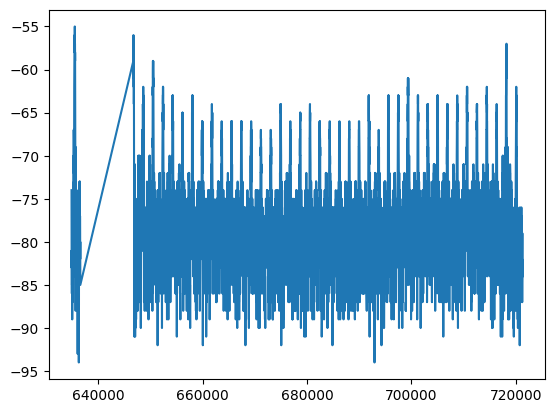

In [4]:
plt.plot([i[3] for i in testsigs.data],[i[0] for i in testsigs.data])
plt.show()

Cut off the first and last bursts as they were taken when we were setting up and turning off the reciever, therefore were subject to additional obstructions

In [5]:
testsigs.data = testsigs.data[250:len(testsigs.data)-10]

Since we can't exactly know what true angle the reciever was located at from the transmitter in the test data due to human error of where we placed the reciever (in this test, aimed to be at 0 degrees), we will instead use the average of the angles in the packets with peak RSSIs of every transmitter rotation that was meausred.

In [6]:
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
peaks = []
for b in burst:
    maxind = np.argmax(b['rssis'])
    peaks.append(b['angles'][maxind])

groundTruthAngle = 360 - np.rad2deg(circmean(peaks)) % 360
print("True angle = " + str(groundTruthAngle))

True angle = 266.9461548619557


# Inference Example

Choose a burst scan:

In [133]:
burstIndex = 10
nSamps = 100

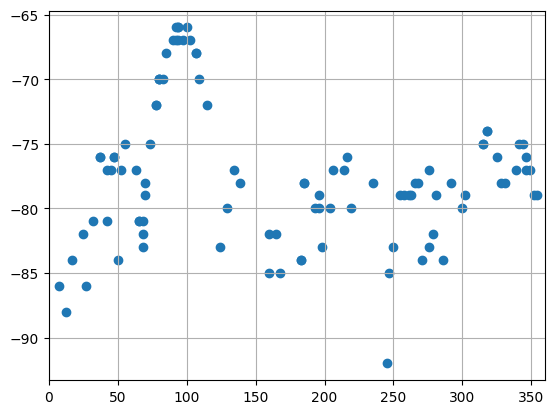

In [134]:
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
currentBurst = randomSampleFromBurstDict(burst[burstIndex], nSamps)
plt.scatter(np.rad2deg(currentBurst['angles']), currentBurst['rssis'])
plt.xlim(0,360)
plt.grid()

Probability via pattern matching:

Standardising angles and times (shifting by 38.00 degrees)

Highest density at angle: 262
99.97812537863368


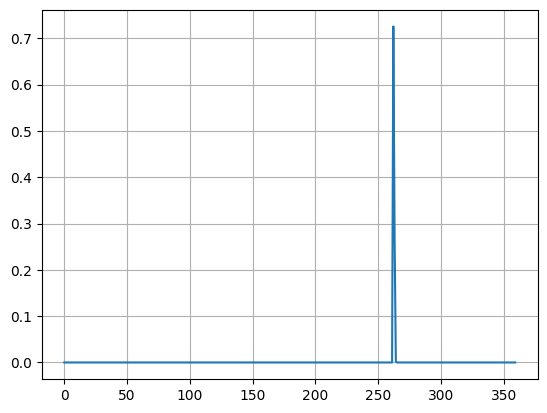

In [135]:
import scipy
angles = AnglesUsePatternMeans(noisevar=3**2)

logps,_,_,_ = angles.infer(currentBurst['rssis'],currentBurst['angles'])
#logps = np.log(np.exp(logps)+1e-1000)
ps = normalise_logs_to_ps(logps)
plt.plot(np.linspace(0,359,360),ps)
#print(np.max(logps),np.max(ps),np.sum(ps))

def WeightedCircStd(pdf):
    sumEi = 0
    for p in pdf:
        sumEi += np.exp(1)**()
    print()
    return np.sqrt(-2*np.log(np.abs(sumEi)))

def yamartino(thetalist):
    s=0
    c=0
    n=0.0
    for theta in thetalist:
        s=s+np.sin(np.deg2rad(theta))
        c=c+np.cos(np.deg2rad(theta))
        n+=1
    s=s/n
    c=c/n
    eps=(1-(s**2+c**2))**0.5
    sigma=np.arcsin(eps)*(1+(2.0/3.0**0.5-1)*eps**3)
    return np.rad2deg(sigma)

        
#plt.ylim([-0.001,1]) #1.1*np.max(ps)])
plt.grid()
print()
angles = AnglesUsePeaks(100)
prediction = angles.infer(currentBurst['rssis'],currentBurst['angles'])
print("Highest density at angle: " + str(np.argmax(logps)))
print(yamartino(logps))

Smoothing and peak finding:

In [63]:
angles = AnglesUsePeaks(100)
prediction = angles.infer(currentBurst['rssis'],currentBurst['angles'])
print(np.rad2deg(prediction))

nan


Rejection sampling:

Circular average of sampled angles: 187.97947454692311


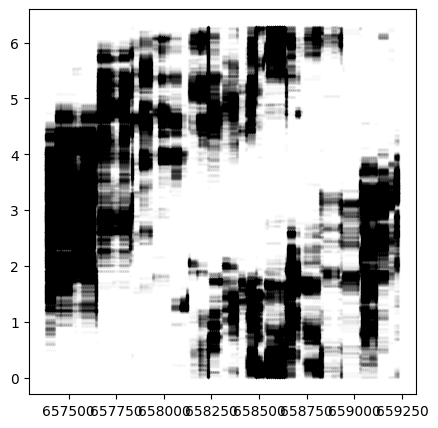

In [53]:
# TODO : Make result clockwise in the graph
results = rejectionSampling.inferFromBurst(currentBurst,filter = False, plot = True, filterMean = 3, filterStd = 1)
print("Circular average of sampled angles: " + str(np.rad2deg(circmean([x[1] for x in results]))))

# Tabulated comparison

In [42]:
# Load data and define tests to perform
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
nSamps = [5,10,25,50,100,150]
nTests = 10
result = np.zeros((len(nSamps), 3))

anglesPattern = AnglesUsePatternMeans(noisevar=3**2)
anglesPeak = AnglesUsePeaks(100)

# For each specified number of samples
for x, n in enumerate(nSamps):
    # Repeat test nTests times
    for i in range(nTests):
        # Select burst and randomly sample from it
        burstIndex = np.random.randint(0, len(burst))
        currentBurst = randomSampleFromBurstDict(burst[burstIndex], n)

        # Get prediction from probability distribution
        logps,_,_,_ = anglesPattern.infer(currentBurst['rssis'],currentBurst['angles'])
        ps = normalise_logs_to_ps(logps)
        result[x][0] += angularDistance(groundTruthAngle, np.argmax(ps))

        # Get prediction from peak finding heuristic
        prediction = anglesPeak.infer(currentBurst['rssis'],currentBurst['angles'])
        result[x][1] += angularDistance(groundTruthAngle, np.rad2deg(prediction))

        # Get prediction from rejection sampling 
        predictions = rejectionSampling.inferFromBurst(currentBurst,filter = True, plot = False,
                                                   filterMean = 0, filterStd = 2)
        prediction = np.rad2deg(circmean(predictions))
        result[x][2] += angularDistance(groundTruthAngle,prediction)

    # Calculate MAE for each method
    MAE = np.round(result/nTests,2)

Standardising angles and times (shifting by 38.00 degrees)


/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:214: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


In [43]:
df = pd.DataFrame(MAE)
df = df.rename(index={0: str(nSamps[0]), 1: str(nSamps[1]), 2: str(nSamps[2]), 3: str(nSamps[3]), 4: str(nSamps[4]), 5: str(nSamps[5])})
df.columns = ["Pattern Matching", "Peak Finding","Rejection Sampling"]
print(df)

     Pattern Matching  Peak Finding  Rejection Sampling
5               66.72         98.09               72.02
10              52.68         36.41               44.83
25               2.95         17.98               29.47
50               1.61         52.80               32.35
100              2.36         19.22               32.57
150              1.97         33.83               27.90


# Graphical example of comparison